In [1]:
# 1. Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


**Cette section charge toutes les bibliothèques Python nécessaires pour l’analyse de données, la visualisation et la régression.
Sans ces imports, aucune manipulation ou modélisation ne peut être effectuée.**

In [2]:
# 2. Uploading the CSV file

from google.colab import files

# Upload CSV file manually in Colab
uploaded = files.upload()

# Automatically take the first uploaded file
file_name = list(uploaded.keys())[0]

# Load dataset into a pandas DataFrame
df = pd.read_csv(file_name)

# Display first rows
df.head()


Saving Delivery_Logistics.csv to Delivery_Logistics.csv


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


**Cette partie permet de téléverser votre dataset dans Google Colab via files.upload().
Le fichier est ensuite chargé dans un DataFrame pandas pour pouvoir être analysé.**

In [3]:
# 3. Data understanding and cleaning

# Basic info about the dataset
print("=== DataFrame Info ===")
df.info()

# Statistical summary for numeric columns
print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe())

# Check missing values per column
print("\n=== Missing Values per Column ===")
print(df.isna().sum())

# Handling missing values:
# - For numeric columns: fill with median
# - For non-numeric columns: fill with mode (most frequent)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill numeric missing values with median
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Fill categorical missing values with mode if available
for col in categorical_cols:
    if df[col].mode().shape[0] > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

# Verify missing values after filling
print("\n=== Missing Values After Handling ===")
print(df.isna().sum())

# Remove duplicates if they exist
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()

print(f"\nDuplicates before: {duplicates_before}")
print(f"Duplicates after:  {duplicates_after}")

# Show updated shape of the DataFrame
print("\n=== Updated DataFrame Shape ===")
print(df.shape)


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4)

**Ici, on vérifie la structure du dataset, les types de données, les statistiques descriptives, les valeurs manquantes et les doublons.
Le nettoyage garantit que les données sont propres et prêtes pour la modélisation.**

=== Numeric Columns Used for EDA ===
['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost']


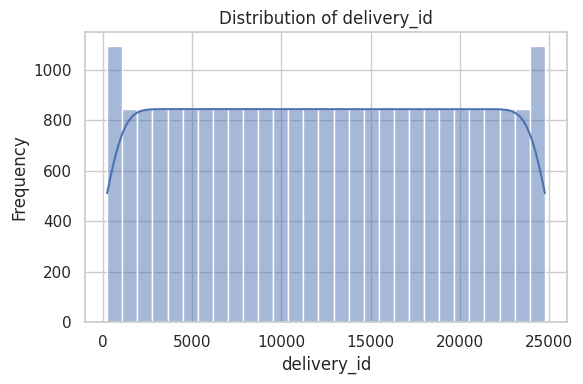

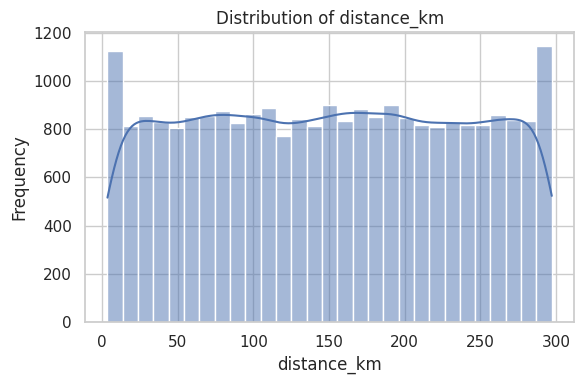

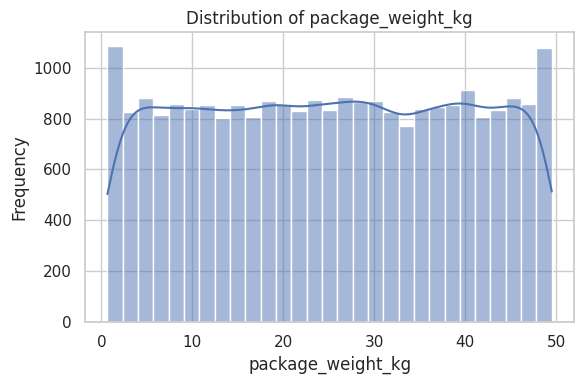

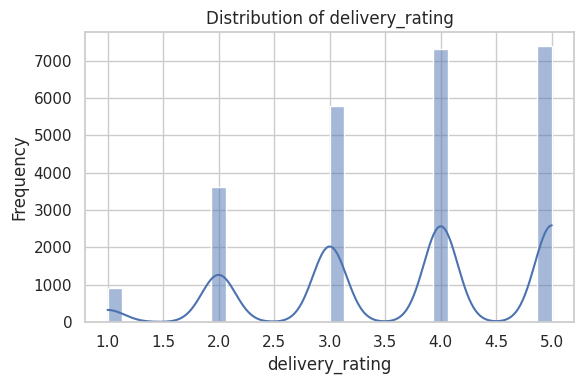

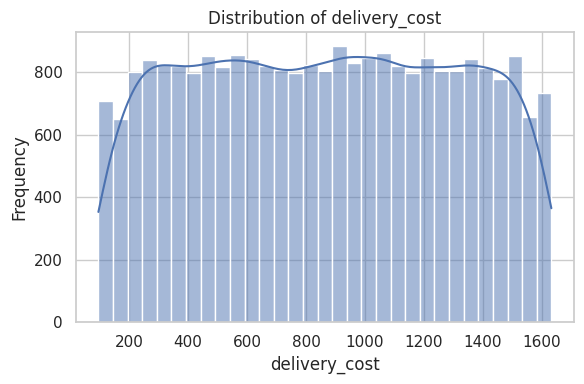

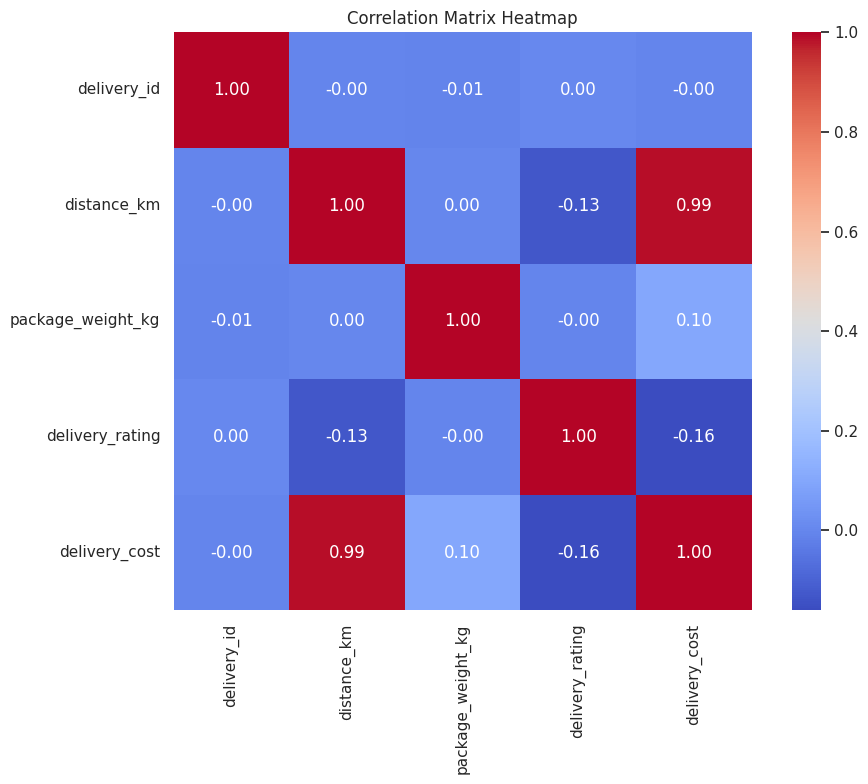

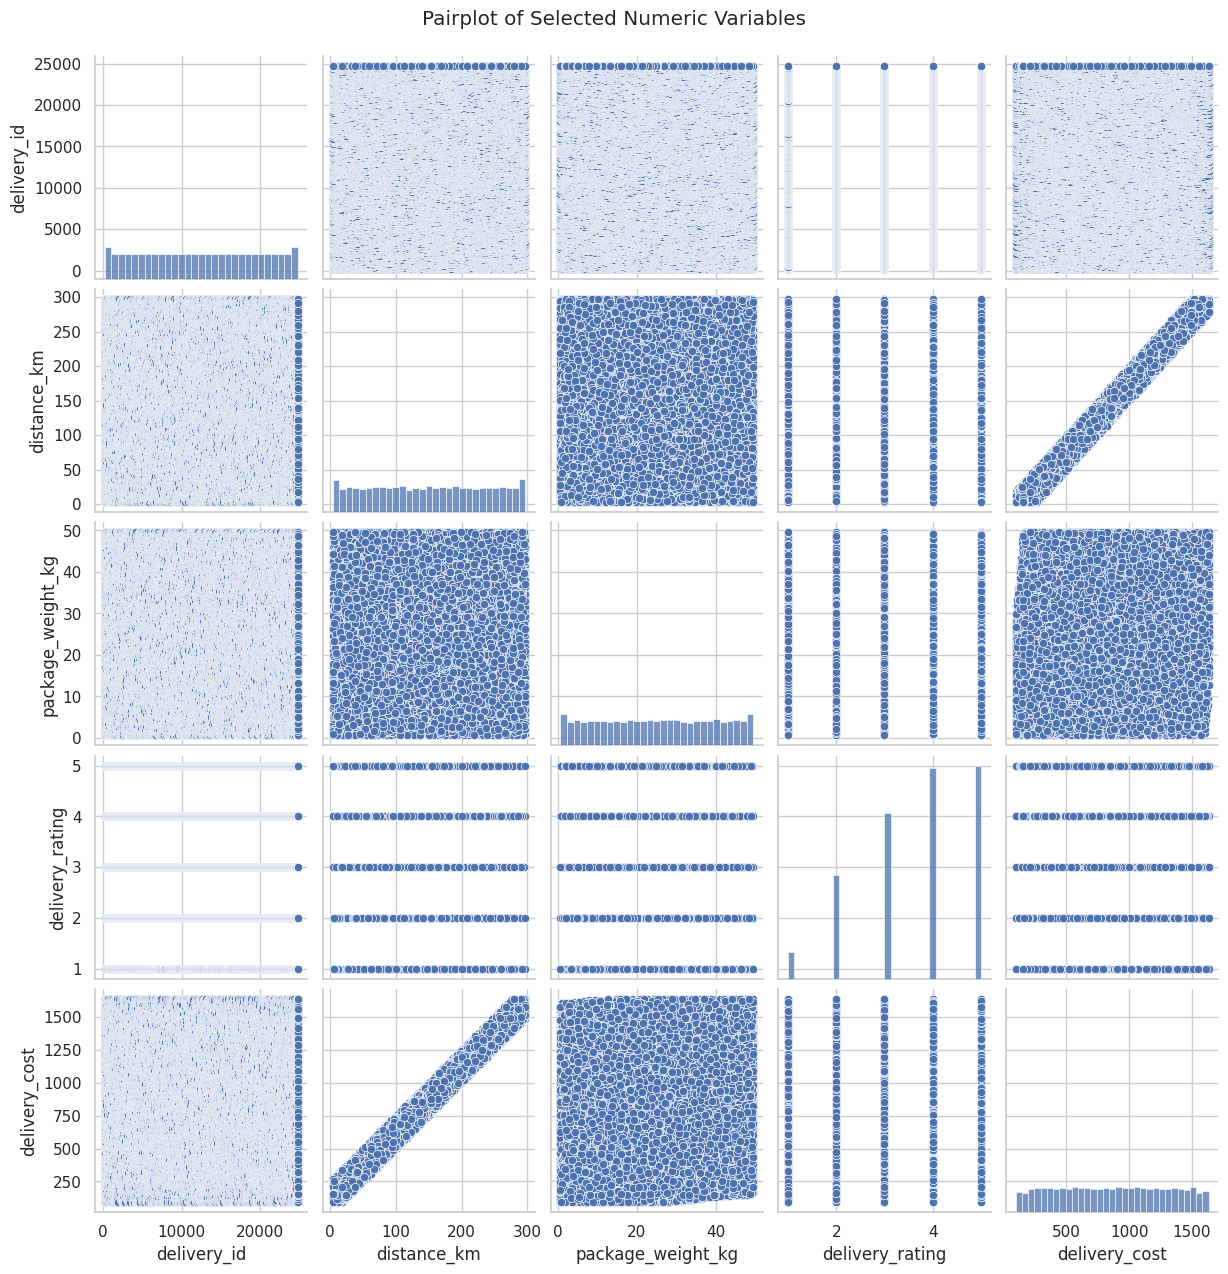

In [4]:
# 4. Exploratory Data Analysis (EDA)

# Select numeric columns for EDA
numeric_cols = df.select_dtypes(include=[np.number])

print("=== Numeric Columns Used for EDA ===")
print(numeric_cols.columns.tolist())

# 4.1 Distribution plots for numeric columns
for col in numeric_cols.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 4.2 Correlation matrix and heatmap
plt.figure(figsize=(10, 8))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

# 4.3 Pairplot (limited to at most 5 numeric variables to keep it readable)
max_vars_pairplot = 5
selected_for_pairplot = numeric_cols.columns[:max_vars_pairplot]

if len(selected_for_pairplot) > 1:
    sns.pairplot(df[selected_for_pairplot])
    plt.suptitle("Pairplot of Selected Numeric Variables", y=1.02)
    plt.show()
else:
    print("\nNot enough numeric variables for pairplot (need at least 2).")


**On visualise les distributions des variables numériques, les corrélations et les relations entre variables.
L’EDA aide à comprendre les tendances, anomalies et facteurs pouvant influencer la variable cible.**

In [5]:
# 5. Feature selection

# Recompute numeric columns in case previous steps modified df
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Safety check: ensure we have at least one numeric column
if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found. Regression requires at least one numeric target.")

# Choose target variable (Y) as the last numeric column (can be adapted manually if needed)
target_col = numeric_cols[-1]

# Features (X) will be all other columns except the target
feature_cols = [col for col in df.columns if col != target_col]

print("=== Target Variable (Y) ===")
print(target_col)

print("\n=== Feature Variables (X) ===")
print(feature_cols)

# Separate features and target
X = df[feature_cols]
y = df[target_col]

# Convert categorical features to dummy/indicator variables for regression
X = pd.get_dummies(X, drop_first=True)

print("\n=== Shape of Features and Target After Encoding ===")
print("X shape:", X.shape)
print("y shape:", y.shape)


=== Target Variable (Y) ===
delivery_cost

=== Feature Variables (X) ===
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating']

=== Shape of Features and Target After Encoding ===
X shape: (25000, 67)
y shape: (25000,)


**Cette étape sépare la variable cible (Y) des variables explicatives (X).
On encode aussi les variables catégorielles en variables numériques (one-hot encoding) pour les rendre compatibles avec la régression.**

In [6]:
# 6. Train/Test split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (20000, 67)
X_test shape: (5000, 67)
y_train shape: (20000,)
y_test shape: (5000,)


**On divise le dataset en données d’entraînement (80%) et données de test (20%).
Cela permet d’évaluer le modèle sur des données jamais vues et d’éviter le surapprentissage (overfitting).**

In [7]:
# 7. Regression model

# Initialize the Linear Regression model
lin_reg = LinearRegression()

# Train the model on the training data
lin_reg.fit(X_train, y_train)

# Print intercept and coefficients
print("=== Linear Regression Model Parameters ===")
print(f"Intercept (b0): {lin_reg.intercept_}")

coefficients = pd.Series(lin_reg.coef_, index=X_train.columns)
print("\nCoefficients (bi for each Xi):")
print(coefficients)

# Display model formula (simplified text form)
formula_parts = [f"({coef:.4f} * {name})" for name, coef in coefficients.items()]
formula_str = " + ".join(formula_parts)
print("\n=== Approximate Regression Formula ===")
print(f"{target_col} = {lin_reg.intercept_:.4f} + {formula_str}")


=== Linear Regression Model Parameters ===
Intercept (b0): 53.046509227249885

Coefficients (bi for each Xi):
delivery_id                                           0.000003
distance_km                                           4.986783
package_weight_kg                                     2.952245
delivery_rating                                       0.014869
delivery_partner_blue dart                            0.017306
                                                       ...    
expected_time_hours_1970-01-01 00:00:00.000000016   -24.297113
expected_time_hours_1970-01-01 00:00:00.000000024   -24.385650
delayed_yes                                          -0.363744
delivery_status_delivered                             0.363744
delivery_status_failed                               -0.184083
Length: 67, dtype: float64

=== Approximate Regression Formula ===
delivery_cost = 53.0465 + (0.0000 * delivery_id) + (4.9868 * distance_km) + (2.9522 * package_weight_kg) + (0.0149 * delivery_rati

**On entraîne un modèle LinearRegression() sur les données d’entraînement.
L’intercept et les coefficients sont affichés pour montrer l’influence de chaque variable sur la cible.**

In [8]:
# 8. Predictions & Evaluation

# Predict on the test set
y_pred = lin_reg.predict(X_test)

# Compute regression metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("=== Regression Evaluation Metrics on Test Set ===")
print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"MSE (Mean Squared Error):         {mse:.4f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:.4f}")
print(f"MAE (Mean Absolute Error):        {mae:.4f}")


=== Regression Evaluation Metrics on Test Set ===
R² (Coefficient of Determination): 0.9999
MSE (Mean Squared Error):         21.7816
RMSE (Root Mean Squared Error):   4.6671
MAE (Mean Absolute Error):        1.6064


**Le modèle réalise des prédictions sur l’échantillon test.
On calcule ensuite plusieurs métriques : R², MSE, RMSE, MAE.
Ces indicateurs mesurent la performance et l’exactitude du modèle.**

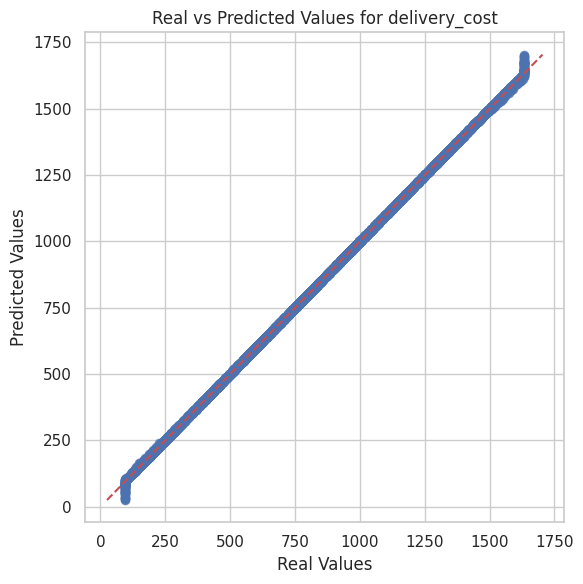

In [9]:
# 9. Real vs Predicted visualization

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.title(f"Real vs Predicted Values for {target_col}")
plt.xlabel("Real Values")
plt.ylabel("Predicted Values")

# Add reference diagonal line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.tight_layout()
plt.show()


**On trace un graphique de comparaison entre les valeurs réelles et les valeurs prédites.
La ligne diagonale représente une prédiction parfaite : plus les points sont proches, meilleur est le modèle.**

In [10]:
# 10. Final summary cell

print("=== Final Summary ===\n")

# Sort features by absolute coefficient value to see influence
coeff_abs = coefficients.abs().sort_values(ascending=False)

print("Top variables influencing the target (by absolute coefficient):")
for feature_name, coef_value in coeff_abs.head(10).items():
    sign = "positive" if coefficients[feature_name] > 0 else "negative"
    print(f"- {feature_name}: {coefficients[feature_name]:.4f} ({sign} impact)")

print("\nInterpretation of R²:")
print(f"- R² = {r2:.4f}")
print("- R² close to 1 means the model explains most of the variability in the target variable.")
print("- R² close to 0 means the model does not explain much of the variability.")
print("- Use this value to judge how well the linear model fits your data.")


=== Final Summary ===

Top variables influencing the target (by absolute coefficient):
- delivery_mode_same day: 43.4260 (positive impact)
- expected_time_hours_1970-01-01 00:00:00.000000024: -24.3856 (negative impact)
- delivery_mode_standard: -24.3856 (negative impact)
- expected_time_hours_1970-01-01 00:00:00.000000016: -24.2971 (negative impact)
- delivery_mode_two day: -24.2971 (negative impact)
- expected_time_hours_1970-01-01 00:00:00.000000008: 6.5227 (positive impact)
- distance_km: 4.9868 (positive impact)
- delivery_time_hours_1970-01-01 00:00:00.000000016: -4.0299 (negative impact)
- package_weight_kg: 2.9522 (positive impact)
- expected_time_hours_1970-01-01 00:00:00.000000006: 2.1851 (positive impact)

Interpretation of R²:
- R² = 0.9999
- R² close to 1 means the model explains most of the variability in the target variable.
- R² close to 0 means the model does not explain much of the variability.
- Use this value to judge how well the linear model fits your data.


**Ce bloc affiche un résumé simple :**

**les variables les plus influentes selon les coefficients,**

**l’interprétation du score R².**

**Cela permet de comprendre ce que le modèle a appris et sa qualité globale.**